In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import timm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
base_transform = transforms.Resize((256, 256))

eff_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3,0.3,0.3,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

vit_transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [10]:
class HybridDataset(Dataset):
    def __init__(self, dataset, train=True):
        self.dataset = dataset
        self.train = train

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        base = base_transform(img)

        if self.train:
            eff_img = eff_transform(base)
            vit_img = vit_transform(base)
        else:
            eff_img = val_transform(base)
            vit_img = val_transform(base)

        return eff_img, vit_img, label

In [11]:
full_dataset = datasets.ImageFolder("/home/ex5/Downloads/Cashew_Dataset")

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

In [12]:
train_dataset = HybridDataset(train_ds, train=True)
val_dataset = HybridDataset(val_ds, train=False)
test_dataset = HybridDataset(test_ds, train=False)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.eff = timm.create_model('efficientnet_b0', pretrained=True)
        self.eff.classifier = nn.Identity()

        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.vit.head = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(1280 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, eff_img, vit_img):
        eff_feat = self.eff(eff_img)
        vit_feat = self.vit(vit_img)

        combined = torch.cat((eff_feat, vit_feat), dim=1)
        return self.fc(combined)

In [15]:
num_classes = len(full_dataset.classes)

model = HybridModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5) 

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [16]:
EPOCHS = 200
best_val_loss = float('inf')
patience = 15
counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for eff_img, vit_img, labels in train_loader:
        eff_img, vit_img, labels = eff_img.to(device), vit_img.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(eff_img, vit_img)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for eff_img, vit_img, labels in val_loader:
            eff_img, vit_img, labels = eff_img.to(device), vit_img.to(device), labels.to(device)

            outputs = model(eff_img, vit_img)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(torch.load("best_hybrid_model.pth"))
model.eval()

print("\nTraining Complete.")


Epoch [1/200]
Train Loss: 0.2713 | Train Acc: 0.9149
Val Loss: 0.2823 | Val Acc: 0.8921

Epoch [2/200]
Train Loss: 0.1355 | Train Acc: 0.9596
Val Loss: 0.1941 | Val Acc: 0.9389

Epoch [3/200]
Train Loss: 0.1110 | Train Acc: 0.9651
Val Loss: 0.1647 | Val Acc: 0.9542

Epoch [4/200]
Train Loss: 0.0837 | Train Acc: 0.9747
Val Loss: 0.1744 | Val Acc: 0.9450

Epoch [5/200]
Train Loss: 0.0598 | Train Acc: 0.9854
Val Loss: 0.2074 | Val Acc: 0.9430

Epoch [6/200]
Train Loss: 0.0596 | Train Acc: 0.9806
Val Loss: 0.2004 | Val Acc: 0.9552

Epoch [7/200]
Train Loss: 0.0429 | Train Acc: 0.9867
Val Loss: 0.1942 | Val Acc: 0.9532

Epoch [8/200]
Train Loss: 0.0419 | Train Acc: 0.9867
Val Loss: 0.1806 | Val Acc: 0.9582

Epoch [9/200]
Train Loss: 0.0251 | Train Acc: 0.9911
Val Loss: 0.1679 | Val Acc: 0.9664

Epoch [10/200]
Train Loss: 0.0098 | Train Acc: 0.9974
Val Loss: 0.1603 | Val Acc: 0.9674

Epoch [11/200]
Train Loss: 0.0042 | Train Acc: 0.9989
Val Loss: 0.1709 | Val Acc: 0.9664

Epoch [12/200]
Tra

/tmp/ipykernel_5445/614121594.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_hybrid_model.pth"))


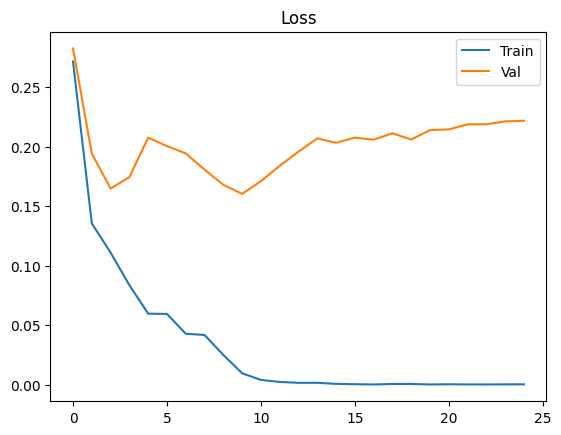

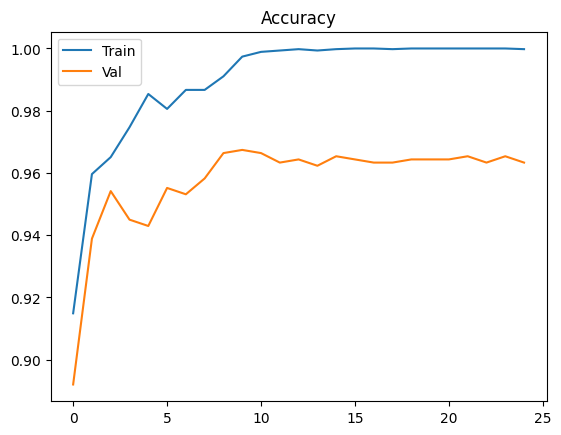

In [17]:
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

In [18]:
all_preds, all_labels = [], []

with torch.no_grad():
    for eff_img, vit_img, labels in test_loader:
        eff_img, vit_img, labels = eff_img.to(device), vit_img.to(device), labels.to(device)

        outputs = model(eff_img, vit_img)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

Test Accuracy: 0.965412004069176
                    precision    recall  f1-score   support

Cashew anthracnose       0.97      0.92      0.94       270
    Cashew gumosis       1.00      0.97      0.98        62
    Cashew healthy       0.96      0.99      0.97       195
 Cashew leaf miner       0.93      0.97      0.95       205
   Cashew red rust       0.99      0.99      0.99       251

          accuracy                           0.97       983
         macro avg       0.97      0.97      0.97       983
      weighted avg       0.97      0.97      0.97       983



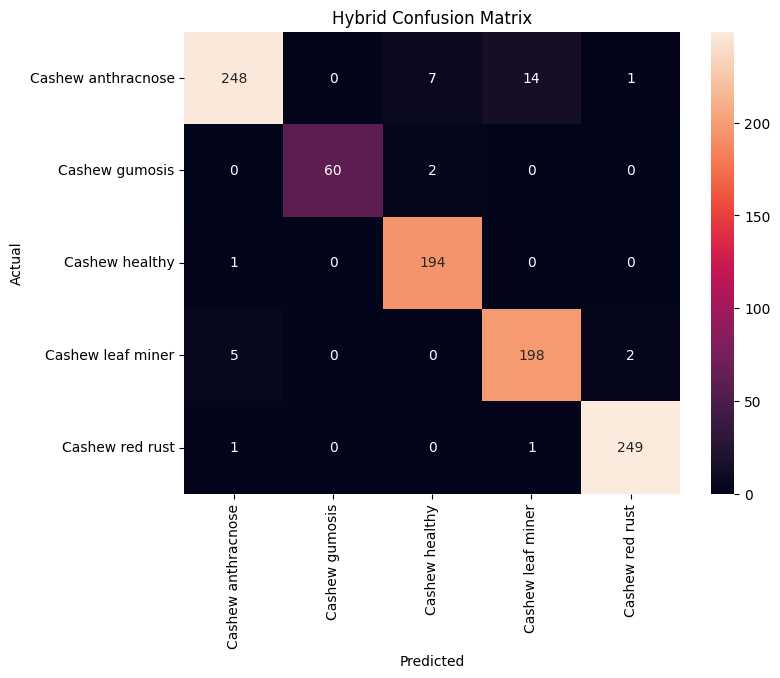

In [19]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.title("Hybrid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()